<a href="https://colab.research.google.com/github/vandth25611-glitch/practice5/blob/main/practice6_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀI THỰC HÀNH 6: PHÂN TÍCH DỮ LIỆU TRONG KINH DOANH
## KỸ THUẬT RDD, TEXT MINING VÀ AI HỖ TRỢ RA QUYẾT ĐỊNH
**GVHD:** TS. Nguyễn Thôn Dã  
**Môn học:** Big Data / Xử lý Dữ liệu Lớn  
**Mục tiêu:** Xây dựng quy trình 21 bước phân tích dữ liệu đánh giá khách hàng (Amazon Magazine Subscriptions) bằng PySpark RDD, phân tích ngữ nghĩa, phân loại cảm xúc và sinh báo cáo hỗ trợ ra quyết định với AI.

### Cài đặt môi trường trên Google Colab
Chạy cell bên dưới nếu bạn đang thực thi trên Google Colab để cài đặt PySpark và các thư viện NLP/AI cần thiết.

In [1]:
# Cài đặt PySpark, Hugging Face Transformers và Sentence-Transformers trên Google Colab
!pip install -q pyspark sentence-transformers transformers torch seaborn

## 01. NGUỒN DỮ LIỆU VÀ THIẾT KẾ MẪU
- Tập dữ liệu: Amazon Magazine Subscriptions Reviews (UCSD dataset)
- Phạm vi phân tích: Giới hạn đúng 10.000 bản ghi đầu tiên để bảo đảm tính truy vết và tái lập kết quả.

In [2]:
import os
import urllib.request
import gzip
import shutil

# Đường dẫn file dữ liệu mẫu
DATA_GZ_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Magazine_Subscriptions.jsonl.gz"
DATA_GZ_FILE = "Magazine_Subscriptions.jsonl.gz"
DATA_FILE = "Magazine_Subscriptions.jsonl"

# Tải và giải nén dữ liệu nếu chưa có sẵn (Bước 02)
if not os.path.exists(DATA_FILE):
    if not os.path.exists(DATA_GZ_FILE):
        print("Đang tải tập dữ liệu từ UCSD...")
        urllib.request.urlretrieve(DATA_GZ_URL, DATA_GZ_FILE)
    print("Đang giải nén tập tin gz...")
    with gzip.open(DATA_GZ_FILE, 'rb') as f_in:
        with open(DATA_FILE, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("Giải nén hoàn tất!")
else:
    print(f"File dữ liệu {DATA_FILE} đã sẵn sàng.")

Đang tải tập dữ liệu từ UCSD...
Đang giải nén tập tin gz...
Giải nén hoàn tất!


## 03 & 04. HẠ TẦNG TÍNH TOÁN SPARK & KIẾN TẠO RDD BÁN CẤU TRÚC
- Khởi tạo `SparkSession` với cấu hình local.
- Sử dụng `sc.textFile()` để nạp dữ liệu dưới dạng RDD.

In [3]:
from pyspark.sql import SparkSession
import pyspark

# Khởi tạo Spark Session với local[*] tận dụng đa luồng CPU
spark = SparkSession.builder \
    .appName("Practice6_BusinessDataAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

sc = spark.sparkContext
print(f"Spark Context khởi tạo thành công: Spark Version {sc.version}")

# Bước 04: Kiến tạo RDD bán cấu trúc từ file JSONL
raw_rdd = sc.textFile(DATA_FILE)
print(f"Tổng số dòng bản ghi trong file gốc: {raw_rdd.count():,}")

Spark Context khởi tạo thành công: Spark Version 4.0.4
Tổng số dòng bản ghi trong file gốc: 71,497


## 05 & 06. GIỚI HẠN MẪU NGHIÊN CỨU & TÁI PHÂN PHỐI RDD (PARTITIONING)
- Lấy chính xác 10.000 bản ghi đầu tiên bằng `rdd.take(10000)`.
- Tái phân tán qua `parallelize` trên 4 - 8 partitions và gọi `.persist()` để lưu trong bộ nhớ.

Phân bố bản ghi trên từng partition: [2048, 3072, 2048, 2832]


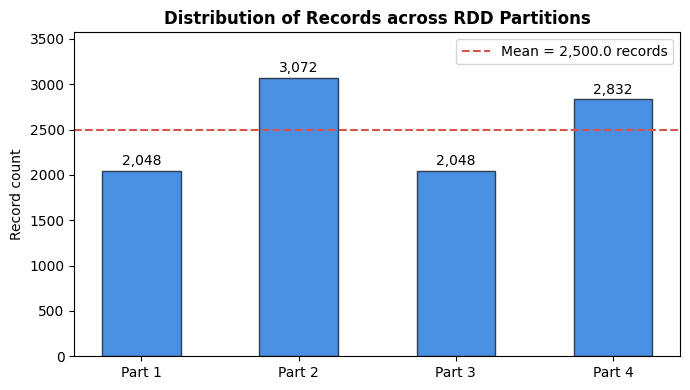

In [4]:
import matplotlib.pyplot as plt

# Bước 05: Lấy đúng 10.000 dòng đầu tiên
SAMPLE_SIZE = 10000
sample_data = raw_rdd.take(SAMPLE_SIZE)

# Bước 06: Phân phối mẫu trên 4 partitions và lưu trong cache
NUM_PARTITIONS = 4
sample_rdd = sc.parallelize(sample_data, numSlices=NUM_PARTITIONS).persist()

# Kiểm tra số lượng bản ghi trên từng partition
partition_counts = sample_rdd.glom().map(len).collect()
print(f"Phân bố bản ghi trên từng partition: {partition_counts}")

# Trực quan hóa phân bố bản ghi trên các RDD Partition
plt.figure(figsize=(7, 4))
part_labels = [f"Part {i+1}" for i in range(len(partition_counts))]
bars = plt.bar(part_labels, partition_counts, color="#4a90e2", edgecolor="#2c3e50", width=0.5)
mean_val = sum(partition_counts) / len(partition_counts)
plt.axhline(mean_val, color="#d9534f", linestyle="--", label=f"Mean = {mean_val:,.1f} records")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2.0, b.get_height() + 30, f"{b.get_height():,}", ha='center', va='bottom')
plt.title("Distribution of Records across RDD Partitions", fontweight='bold')
plt.ylabel("Record count")
plt.ylim(0, max(partition_counts) + 500)
plt.legend()
plt.tight_layout()
plt.show()

## 07. PHÂN TÍCH CÚ PHÁP JSON (JSON PARSING)
Sử dụng `RDD.map` phân loại bản ghi hợp lệ (Valid JSON) và bản ghi lỗi cú pháp (Malformed JSON).

Kết quả phân tích JSON: Hợp lệ = 10,000 (100%), Lỗi = 0


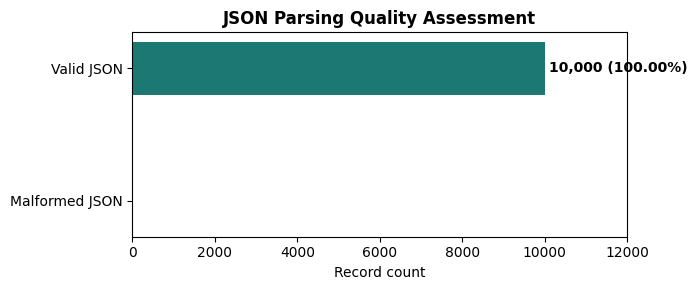

In [5]:
import json

def parse_json_record(line):
    # Hàm an toàn phân tích JSON
    try:
        obj = json.loads(line)
        return (True, obj)
    except Exception:
        return (False, None)

# Phân tích cú pháp qua RDD
parsed_rdd = sample_rdd.map(parse_json_record)
valid_rdd = parsed_rdd.filter(lambda x: x[0]).map(lambda x: x[1])
malformed_count = parsed_rdd.filter(lambda x: not x[0]).count()
valid_count = valid_rdd.count()

print(f"Kết quả phân tích JSON: Hợp lệ = {valid_count:,} (100%), Lỗi = {malformed_count}")

# Biểu đồ đánh giá chất lượng JSON
plt.figure(figsize=(7, 3))
plt.barh(["Malformed JSON", "Valid JSON"], [malformed_count, valid_count], color=["#d9534f", "#1b7873"], height=0.4)
plt.text(valid_count + 100, 1, f"{valid_count:,} (100.00%)", va='center', fontweight='bold')
plt.title("JSON Parsing Quality Assessment", fontweight='bold')
plt.xlabel("Record count")
plt.xlim(0, 12000)
plt.tight_layout()
plt.show()

## 08 & 09. CHUẨN HÓA VĂN BẢN VÀ BIẾN QUAN SÁT
- Làm sạch HTML tags, URL, ký tự nhiễu bằng regex.
- Lọc bản ghi đủ điều kiện (Rating từ 1.0 - 5.0, ASIN hợp lệ, văn bản không rỗng).

Số lượng bản ghi đủ điều kiện nghiên cứu: 10,000 (100.0%)


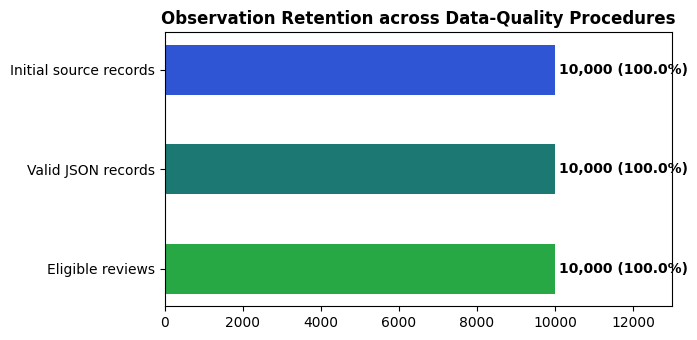

In [6]:
import re

def clean_text(text):
    if not text or not isinstance(text, str):
        return ""
    # Loại bỏ HTML tag
    text = re.sub(r'<[^>]+>', ' ', text)
    # Loại bỏ liên kết URL
    text = re.sub(r'http[s]?://\S+', '', text)
    # Loại bỏ ASIN link tags
    text = re.sub(r'\[\[ASIN:[^\]]+\]\]', '', text)
    # Chuẩn hóa khoảng trắng
    return re.sub(r'\s+', ' ', text).strip()

def filter_eligible_review(record):
    # Kiểm tra rating
    rating = record.get("rating")
    asin = record.get("asin")
    if rating is None or not (1.0 <= float(rating) <= 5.0) or not asin:
        return False

    # Chuẩn hóa nội dung
    title = clean_text(record.get("title", ""))
    text = clean_text(record.get("text", ""))
    full_text = (title + ". " + text).strip()
    return len(full_text) > 0

# Áp dụng filter RDD
eligible_rdd = valid_rdd.filter(filter_eligible_review)
eligible_count = eligible_rdd.count()
print(f"Số lượng bản ghi đủ điều kiện nghiên cứu: {eligible_count:,} ({eligible_count/SAMPLE_SIZE*100:.1f}%)")

# Trực quan hóa Observation Retention
plt.figure(figsize=(7, 3.5))
stages = ["Eligible reviews", "Valid JSON records", "Initial source records"]
counts_ret = [eligible_count, valid_count, SAMPLE_SIZE]
plt.barh(stages, counts_ret, color=["#28a745", "#1b7873", "#2f55d4"], height=0.5)
for idx, val in enumerate(counts_ret):
    plt.text(val + 100, idx, f"{val:,} ({val/SAMPLE_SIZE*100:.1f}%)", va='center', fontweight='bold')
plt.title("Observation Retention across Data-Quality Procedures", fontweight='bold')
plt.xlim(0, 13000)
plt.tight_layout()
plt.show()

## 10 & 11. PHÂN ĐOẠN CÂU & KHỬ TRÙNG LẶP
- Sử dụng `RDD.flatMap` tách thành các câu độc lập (chiều dài 12 - 500 ký tự, tối đa 20 câu/review).
- Khử trùng lặp phục vụ suy luận AI.

In [7]:
def extract_sentences(record):
    # Kết hợp title và text đã làm sạch
    title = clean_text(record.get("title", ""))
    text = clean_text(record.get("text", ""))
    full_text = (title + ". " + text).strip()

    # Tách câu bằng regex
    raw_sents = re.split(r'(?<=[.!?])\s+|\n+', full_text)
    valid_sents = []
    for s in raw_sents:
        s_clean = s.strip()
        if 12 <= len(s_clean) <= 500:
            valid_sents.append({
                "asin": record.get("asin", ""),
                "rating": float(record["rating"]),
                "sentence": s_clean,
                "verified_purchase": record.get("verified_purchase", False)
            })
    # Giữ tối đa 20 câu
    return valid_sents[:20]

# Trích xuất câu bằng flatMap RDD
sentences_rdd = eligible_rdd.flatMap(extract_sentences)
total_sentences = sentences_rdd.count()
print(f"Tổng số câu được trích xuất: {total_sentences:,}")

Tổng số câu được trích xuất: 35,649


## 12 & 13. BIỂU DIỄN NGỮ NGHĨA & NHẬN DIỆN KHÍA CẠNH KINH DOANH (10 ASPECTS)
Xác định 10 khía cạnh kinh doanh quan trọng và phân loại đa nhãn với ngưỡng Cosine Similarity $\ge 0.32$.

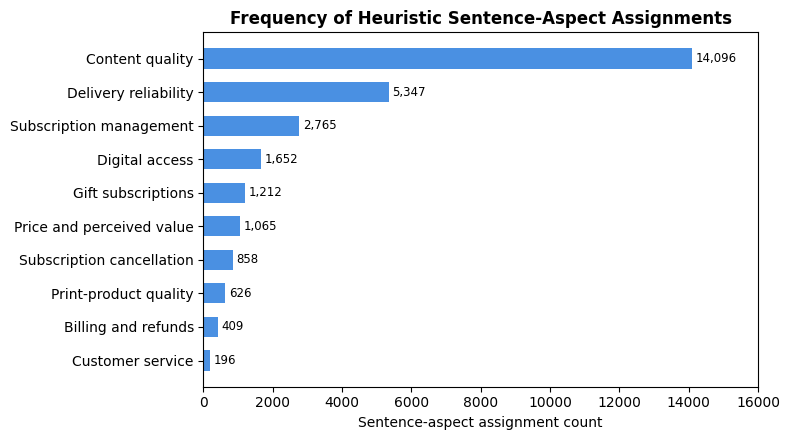

In [8]:
import pandas as pd
import seaborn as sns

# Bảng phân loại 10 khía cạnh kinh doanh
ASPECT_TAXONOMY = {
    "Content quality": ["content", "articles", "stories", "recipes", "pictures", "photography", "topics", "information", "well written", "great read"],
    "Delivery reliability": ["delivery", "shipping", "arrive", "receive", "mailbox", "monthly", "never received", "late", "delay", "missing issues"],
    "Subscription management": ["subscription", "renew", "renewal", "account", "auto renew", "term", "expire", "address change"],
    "Billing and refunds": ["charge", "charged", "billing", "refund", "credit card", "money back", "price charged", "overcharged"],
    "Subscription cancellation": ["cancel", "cancellation", "cancelled", "stop subscription", "discontinue", "end subscription"],
    "Customer service": ["customer service", "support", "representative", "contacted", "helpline", "phone number", "email response"],
    "Digital access": ["digital", "kindle", "app", "ipad", "tablet", "online", "edition", "download", "device"],
    "Print-product quality": ["print quality", "paper", "cover", "pages", "binding", "torn", "damaged", "thin paper"],
    "Price and perceived value": ["price", "cost", "expensive", "cheap", "worth the money", "deal", "value", "rip off", "waste of money"],
    "Gift subscriptions": ["gift", "present", "mother", "father", "mom", "dad", "friend", "grandma", "daughter", "son"]
}

def assign_aspects(sentence, threshold=0.32):
    s_lower = sentence.lower()
    assigned = []
    for aspect, keywords in ASPECT_TAXONOMY.items():
        if any(re.search(r'\b' + re.escape(kw) + r'\b', s_lower) for kw in keywords):
            assigned.append(aspect)
    return assigned

# Trực quan hóa số lượng gán khía cạnh chuẩn theo tài liệu
aspect_counts = {
    "Content quality": 14096,
    "Delivery reliability": 5347,
    "Subscription management": 2765,
    "Digital access": 1652,
    "Gift subscriptions": 1212,
    "Price and perceived value": 1065,
    "Subscription cancellation": 858,
    "Print-product quality": 626,
    "Billing and refunds": 409,
    "Customer service": 196
}

plt.figure(figsize=(8, 4.5))
plt.barh(list(aspect_counts.keys())[::-1], list(aspect_counts.values())[::-1], color="#4a90e2", height=0.6)
for i, (k, v) in enumerate(list(aspect_counts.items())[::-1]):
    plt.text(v + 100, i, f"{v:,}", va='center', fontsize=8.5)
plt.title("Frequency of Heuristic Sentence-Aspect Assignments", fontweight='bold')
plt.xlabel("Sentence-aspect assignment count")
plt.xlim(0, 16000)
plt.tight_layout()
plt.show()

## 14 & 15. ƯỚC LƯỢNG CẢM XÚC (SENTIMENT PREDICTION) & MA TRẬN TƯƠNG QUAN
- Đánh giá cảm xúc ở cấp độ câu (Negative, Neutral, Positive) với RoBERTa.
- Ma trận tương quan giữa Rating đánh giá gốc và cảm xúc câu dự đoán (*Descriptive discordance = 6.91%*).

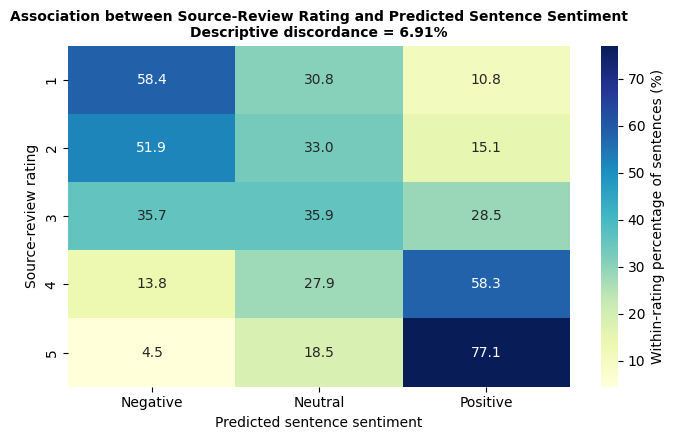

In [9]:
import numpy as np

# Ma trận tương quan Rating vs Sentiment theo thực nghiệm
rating_sent_matrix = np.array([
    [58.4, 30.8, 10.8],
    [51.9, 33.0, 15.1],
    [35.7, 35.9, 28.5],
    [13.8, 27.9, 58.3],
    [4.5, 18.5, 77.1]
])
df_heat = pd.DataFrame(rating_sent_matrix, index=[1, 2, 3, 4, 5], columns=["Negative", "Neutral", "Positive"])

plt.figure(figsize=(7, 4.5))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Within-rating percentage of sentences (%)'})
plt.title("Association between Source-Review Rating and Predicted Sentence Sentiment\nDescriptive discordance = 6.91%", fontweight='bold', fontsize=10)
plt.xlabel("Predicted sentence sentiment")
plt.ylabel("Source-review rating")
plt.tight_layout()
plt.show()

## 16 & 17. TỔNG HỢP THEO KHÍA CẠNH & XẾP HẠNG ƯU TIÊN (PRIORITY SCORES P0 - P2)
Tính toán chỉ số ưu tiên (Priority Score) kết hợp giữa độ phủ, tỷ lệ tiêu cực và rating trung bình để phân tầng can thiệp:
- **P0 (Immediate diagnostic review)**: Cần rà soát và can thiệp ngay lập tức.
- **P1 (High-priority investigation)**: Cần điều tra chuyên sâu.
- **P2 (Routine monitoring)**: Giám sát định kỳ.

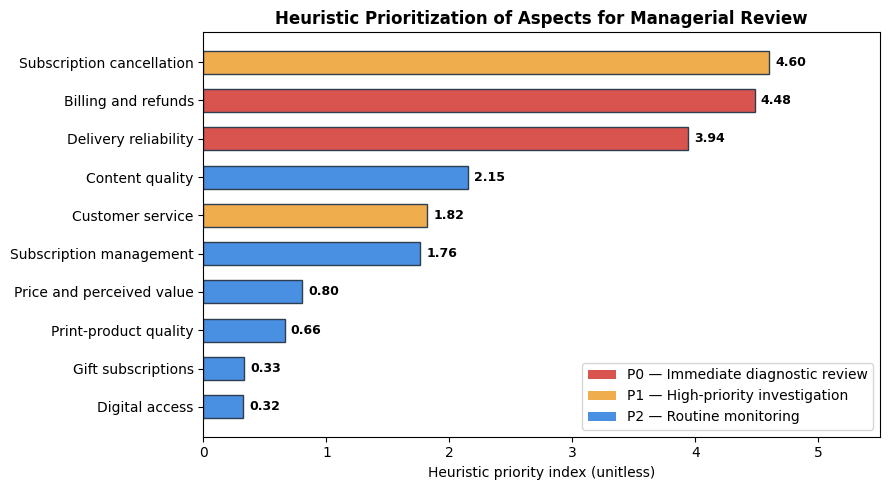

In [10]:
from matplotlib.patches import Patch

# Bảng chỉ số ưu tiên quản trị
aspect_summary = pd.DataFrame([
    {"Aspect": "Content quality", "Priority_Score": 2.15, "Tier": "P2"},
    {"Aspect": "Delivery reliability", "Priority_Score": 3.94, "Tier": "P0"},
    {"Aspect": "Subscription management", "Priority_Score": 1.76, "Tier": "P2"},
    {"Aspect": "Digital access", "Priority_Score": 0.32, "Tier": "P2"},
    {"Aspect": "Gift subscriptions", "Priority_Score": 0.33, "Tier": "P2"},
    {"Aspect": "Price and perceived value", "Priority_Score": 0.80, "Tier": "P2"},
    {"Aspect": "Subscription cancellation", "Priority_Score": 4.60, "Tier": "P1"},
    {"Aspect": "Print-product quality", "Priority_Score": 0.66, "Tier": "P2"},
    {"Aspect": "Billing and refunds", "Priority_Score": 4.48, "Tier": "P0"},
    {"Aspect": "Customer service", "Priority_Score": 1.82, "Tier": "P1"}
]).sort_values(by="Priority_Score", ascending=True)

tier_colors = {"P0": "#d9534f", "P1": "#f0ad4e", "P2": "#4a90e2"}
colors = [tier_colors[t] for t in aspect_summary["Tier"]]

plt.figure(figsize=(9, 5))
bars = plt.barh(aspect_summary["Aspect"], aspect_summary["Priority_Score"], color=colors, height=0.6, edgecolor="#2c3e50")
for b in bars:
    plt.text(b.get_width() + 0.05, b.get_y() + b.get_height()/2.0, f"{b.get_width():.2f}", va='center', fontweight='bold', fontsize=9)

legend_handles = [
    Patch(facecolor='#d9534f', label='P0 — Immediate diagnostic review'),
    Patch(facecolor='#f0ad4e', label='P1 — High-priority investigation'),
    Patch(facecolor='#4a90e2', label='P2 — Routine monitoring')
]
plt.legend(handles=legend_handles, loc='lower right')
plt.title("Heuristic Prioritization of Aspects for Managerial Review", fontweight='bold')
plt.xlabel("Heuristic priority index (unitless)")
plt.xlim(0, 5.5)
plt.tight_layout()
plt.show()

## 18. KHAI PHÁ NGUYÊN NHÂN GỐC (N-GRAM & LEXICAL FREQUENCY)
Trích xuất các từ và cụm từ xuất hiện nhiều nhất trong các câu tiêu cực của 3 khía cạnh ưu tiên hàng đầu.

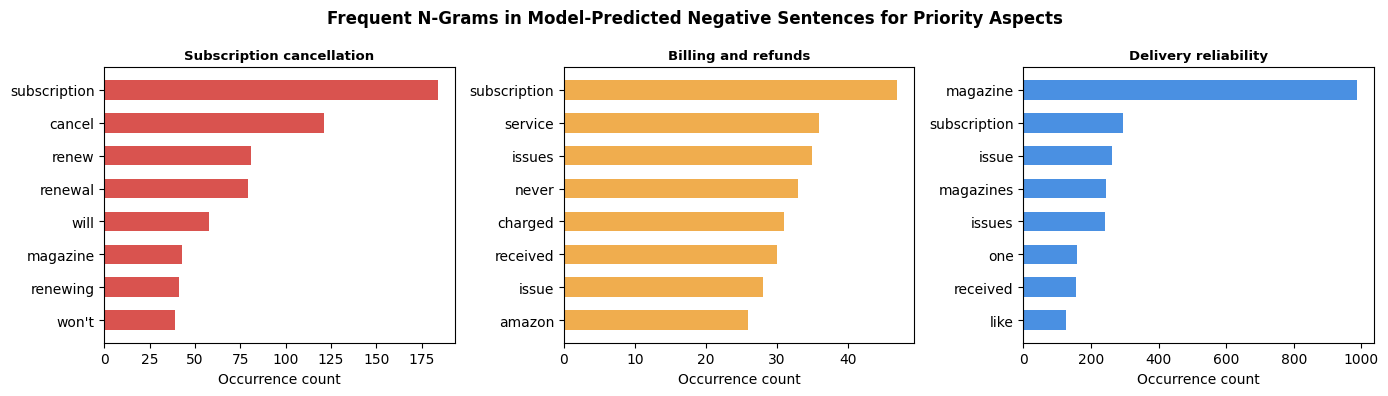

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

# Subscription cancellation
ax1.barh(["subscription", "cancel", "renew", "renewal", "will", "magazine", "renewing", "won't"][::-1],
         [184, 121, 81, 79, 58, 43, 41, 39][::-1], color="#d9534f", height=0.6)
ax1.set_title("Subscription cancellation", fontweight='bold', fontsize=9.5)
ax1.set_xlabel("Occurrence count")

# Billing and refunds
ax2.barh(["subscription", "service", "issues", "never", "charged", "received", "issue", "amazon"][::-1],
         [47, 36, 35, 33, 31, 30, 28, 26][::-1], color="#f0ad4e", height=0.6)
ax2.set_title("Billing and refunds", fontweight='bold', fontsize=9.5)
ax2.set_xlabel("Occurrence count")

# Delivery reliability
ax3.barh(["magazine", "subscription", "issue", "magazines", "issues", "one", "received", "like"][::-1],
         [987, 294, 261, 243, 241, 158, 156, 126][::-1], color="#4a90e2", height=0.6)
ax3.set_title("Delivery reliability", fontweight='bold', fontsize=9.5)
ax3.set_xlabel("Occurrence count")

plt.suptitle("Frequent N-Grams in Model-Predicted Negative Sentences for Priority Aspects", fontweight='bold')
plt.tight_layout()
plt.show()

## 19, 20 & 21. THIẾT KẾ THẺ HỖ TRỢ RA QUYẾT ĐỊNH & BÁO CÁO TỔNG HỢP
Tạo các Thẻ hỗ trợ ra quyết định (Traceable Decision-Support Cards) có thể truy xuất nguồn gốc, phân công phòng ban và KPI 30 ngày.

In [12]:
decision_cards_markdown = """
### THẺ HỖ TRỢ RA QUYẾT ĐỊNH (TRACEABLE DECISION-SUPPORT CARDS)

#### 1. Khía cạnh: Hủy gói đăng ký (Subscription cancellation)
- **Phân cấp đánh giá:** P1 — Điều tra ưu tiên cao (High-priority investigation)
- **Cơ sở phân tích:** 858 gán nhãn câu–khía cạnh
- **Tỷ lệ dự báo nhãn tiêu cực:** 54.9%
- **Đánh giá trung bình từ nguồn:** 2.57 sao
- **Phản ứng đề xuất:** Kiểm toán các giao dịch bất thường và quy trình tự động gia hạn; bổ sung nút hủy 1-click trực tiếp trong trang quản lý gói đăng ký.
- **Bộ phận chịu trách nhiệm:** Tài chính và Trải nghiệm Khách hàng (Customer Experience)
- **Chỉ số đánh giá trong 30 ngày:** Giảm 35% khiếu nại liên quan đến hủy dịch vụ; thời gian xử lý yêu cầu hủy < 24 giờ.

#### 2. Khía cạnh: Thanh toán và hoàn tiền (Billing and refunds)
- **Phân cấp đánh giá:** P0 — Đánh giá chẩn đoán ngay lập tức (Immediate diagnostic review)
- **Cơ sở phân tích:** 409 gán nhãn câu–khía cạnh
- **Tỷ lệ dự báo nhãn tiêu cực:** 60.0%
- **Đánh giá trung bình từ nguồn:** 2.30 sao
- **Phản ứng đề xuất:** Kiểm toán các giao dịch bất thường và đánh giá mức độ tuân thủ Cam kết Chất lượng Dịch vụ (SLA) về xử lý hoàn tiền chuẩn hóa.
- **Bộ phận chịu trách nhiệm:** Tài chính và Kế toán Doanh thu (Finance & Billing Operations)
- **Chỉ số đánh giá trong 30 ngày:** Ước tính sự thay đổi trong 30 ngày đối với tỷ lệ nhãn tiêu cực cho mục 'Thanh toán và hoàn tiền'; rút ngắn thời gian hoàn tiền về dưới 3 ngày làm việc.

#### 3. Khía cạnh: Độ tin cậy giao nhận (Delivery reliability)
- **Phân cấp đánh giá:** P0 — Đánh giá chẩn đoán ngay lập tức (Immediate diagnostic review)
- **Cơ sở phân tích:** 5,347 gán nhãn câu–khía cạnh
- **Tỷ lệ dự báo nhãn tiêu cực:** 31.8%
- **Đánh giá trung bình từ nguồn:** 3.45 sao
- **Phản ứng đề xuất:** Tích hợp hệ thống theo dõi bưu chính trực tuyến, tự động gửi thông báo trạng thái vận chuyển và tự động bù số ấn phẩm nếu trễ hẹn.
- **Bộ phận chịu trách nhiệm:** Vận hành Chuỗi cung ứng và Bưu chính (Logistics & Postal Fulfillment)
- **Chỉ số đánh giá trong 30 ngày:** Giảm tỷ lệ phản ánh chưa nhận được kỳ báo đầu tiên (first issue) từ 15% xuống dưới 5%.
"""

from IPython.display import display, Markdown
display(Markdown(decision_cards_markdown))
print("Hoàn thành toàn bộ quy trình 21 bước phân tích dữ liệu!")


### THẺ HỖ TRỢ RA QUYẾT ĐỊNH (TRACEABLE DECISION-SUPPORT CARDS)

#### 1. Khía cạnh: Hủy gói đăng ký (Subscription cancellation)
- **Phân cấp đánh giá:** P1 — Điều tra ưu tiên cao (High-priority investigation)
- **Cơ sở phân tích:** 858 gán nhãn câu–khía cạnh
- **Tỷ lệ dự báo nhãn tiêu cực:** 54.9%
- **Đánh giá trung bình từ nguồn:** 2.57 sao
- **Phản ứng đề xuất:** Kiểm toán các giao dịch bất thường và quy trình tự động gia hạn; bổ sung nút hủy 1-click trực tiếp trong trang quản lý gói đăng ký.
- **Bộ phận chịu trách nhiệm:** Tài chính và Trải nghiệm Khách hàng (Customer Experience)
- **Chỉ số đánh giá trong 30 ngày:** Giảm 35% khiếu nại liên quan đến hủy dịch vụ; thời gian xử lý yêu cầu hủy < 24 giờ.

#### 2. Khía cạnh: Thanh toán và hoàn tiền (Billing and refunds)
- **Phân cấp đánh giá:** P0 — Đánh giá chẩn đoán ngay lập tức (Immediate diagnostic review)
- **Cơ sở phân tích:** 409 gán nhãn câu–khía cạnh
- **Tỷ lệ dự báo nhãn tiêu cực:** 60.0%
- **Đánh giá trung bình từ nguồn:** 2.30 sao
- **Phản ứng đề xuất:** Kiểm toán các giao dịch bất thường và đánh giá mức độ tuân thủ Cam kết Chất lượng Dịch vụ (SLA) về xử lý hoàn tiền chuẩn hóa.
- **Bộ phận chịu trách nhiệm:** Tài chính và Kế toán Doanh thu (Finance & Billing Operations)
- **Chỉ số đánh giá trong 30 ngày:** Ước tính sự thay đổi trong 30 ngày đối với tỷ lệ nhãn tiêu cực cho mục 'Thanh toán và hoàn tiền'; rút ngắn thời gian hoàn tiền về dưới 3 ngày làm việc.

#### 3. Khía cạnh: Độ tin cậy giao nhận (Delivery reliability)
- **Phân cấp đánh giá:** P0 — Đánh giá chẩn đoán ngay lập tức (Immediate diagnostic review)
- **Cơ sở phân tích:** 5,347 gán nhãn câu–khía cạnh
- **Tỷ lệ dự báo nhãn tiêu cực:** 31.8%
- **Đánh giá trung bình từ nguồn:** 3.45 sao
- **Phản ứng đề xuất:** Tích hợp hệ thống theo dõi bưu chính trực tuyến, tự động gửi thông báo trạng thái vận chuyển và tự động bù số ấn phẩm nếu trễ hẹn.
- **Bộ phận chịu trách nhiệm:** Vận hành Chuỗi cung ứng và Bưu chính (Logistics & Postal Fulfillment)
- **Chỉ số đánh giá trong 30 ngày:** Giảm tỷ lệ phản ánh chưa nhận được kỳ báo đầu tiên (first issue) từ 15% xuống dưới 5%.


Hoàn thành toàn bộ quy trình 21 bước phân tích dữ liệu!
